# Exploratory data analysis: sepsis prediction

Exploration of the processed training split (`data/processed/train.parquet`) to
understand class balance, missingness and how vital signs differ between
septic and non-septic hours. Findings inform the modelling choices in `src/`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from taed2_astra.config import TRAIN_PATH, load_params

In [2]:
params = load_params()
TARGET = params["dataset"]["target"]
GROUP = params["dataset"]["group"]

train = pd.read_parquet(TRAIN_PATH)
train.head()

,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


## 1. Shape and column types

In [3]:
print(f"{train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"{train[GROUP].nunique():,} patients")
train.dtypes.value_counts()

1,241,213 rows x 43 columns
32,268 patients


float64    38
int64       5
Name: count, dtype: int64

## 2. Class balance
Measured per hour-row (what the model scores) and per patient.

In [4]:
row_rate = train[TARGET].mean()
patient_rate = train.groupby(GROUP)[TARGET].max().mean()
print(f"Positive rows: {row_rate:.2%}")
print(f"Patients who develop sepsis: {patient_rate:.2%}")

Positive rows: 1.83%
Patients who develop sepsis: 7.38%


## 3. Missingness

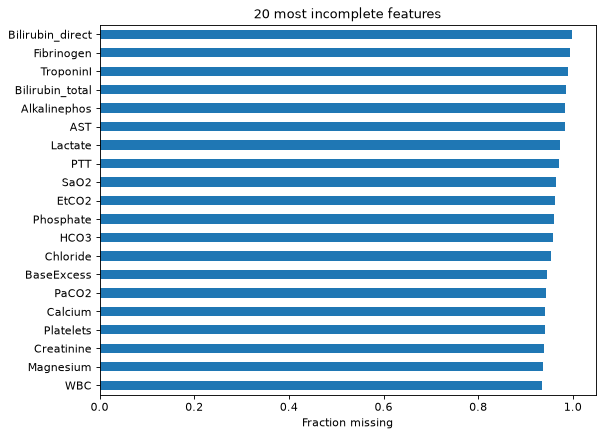

In [5]:
missing = train.drop(columns=[TARGET, GROUP]).isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6), dpi=80)
missing.head(20).plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Fraction missing")
ax.set_title("20 most incomplete features")
plt.show()

## 4. Vital signs by class
A random sample keeps the plot light; the full split has over a million rows.

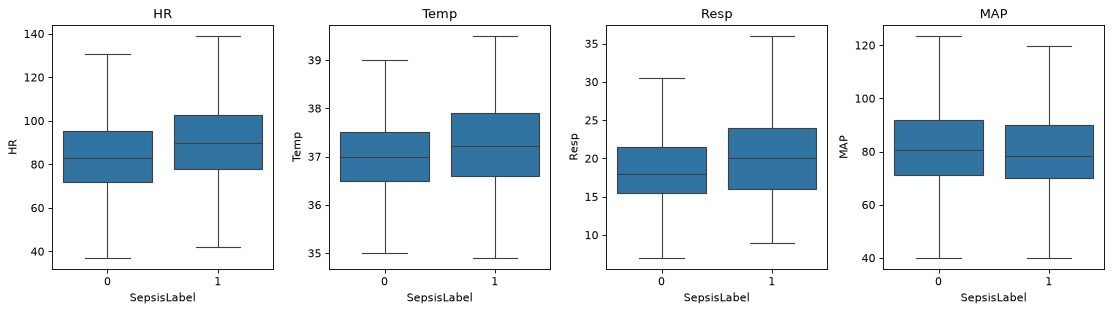

In [6]:
sample = train.sample(n=50_000, random_state=42)
vitals = ["HR", "Temp", "Resp", "MAP"]

fig, axes = plt.subplots(1, len(vitals), figsize=(14, 4), dpi=80)
for ax, col in zip(axes, vitals, strict=False):
    sns.boxplot(data=sample, x=TARGET, y=col, ax=ax, showfliers=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Conclusions
- Strong class imbalance (~2 % positive rows): accuracy is misleading, so PR-AUC is the primary metric.
- Most lab values are >95 % missing; missingness is informative, so the preprocessor keeps missing indicators.
- (Add what you observe in the vital-sign plots.)